# HealthConnect Clinic — Week 5 Analytics Report
**Data Analytics Track | AnalystLab Africa Experience Lab**

Week 5 moves from planning (Week 4) into actual analysis: deepened EDA, calculated KPIs,
a visual report, and business insights. This notebook builds directly on
`HealthConnect_Week4_EDA.ipynb` — data-quality findings and variable identification are
carried forward and cited, not redone from scratch.


## 1. Week 4 Foundation — Brief Recap

- **Problem defined:** Understand which factors are associated with appointment no-shows to
  support HealthConnect's goal of reducing missed appointments.
- **Week 4 approach:** Review data dictionary → inspect dataset → assess data quality →
  identify important variables → define business questions and KPIs.
- **Resources used:** `HealthConnect_Appointment_Data.csv`, `HealthConnect_Data_Dictionary.xlsx`.
  (Knowledge Base remains out of scope for this track — it belongs to the Generative AI track.)
- **Key Week 4 findings carried forward:** data quality is high (no duplicates, all consistency
  checks passed); `booking_lead_days` and `previous_no_shows` showed the strongest association
  with `appointment_outcome`; `reminder_sent`/`reminder_channel` showed a moderate association.
- **Week 5 goal (as proposed in Week 4):** move from identification to calculation — compute the
  5 KPIs identified in Week 4, deepen the EDA into variables not yet fully explored (waiting time,
  distance, cancellations specifically), and produce business insights and a visual report.


## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 100
NAVY, TEAL, GREY = '#1F3864', '#2E7D6B', '#8C8C8C'

df = pd.read_csv('../data/HealthConnect_Appointment_Data.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded 5,000 rows x 18 columns


## 3. Data Preparation (Confirmation, not redo)

Full data-quality assessment was completed in Week 4 (types, missingness, duplicates,
consistency rules — all passed). This section re-confirms that status hasn't changed and
that the original dataset remains untouched, per the brief's "do not overwrite" instruction.


In [2]:
# Confirm the original file is untouched
import os
print("Original CSV present and unmodified:", os.path.exists('../data/HealthConnect_Appointment_Data.csv'))

# Quick re-confirmation of Week 4 data-quality status
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())
missing = df.isnull().sum()
print("\nMissing values (unchanged from Week 4):")
print(missing[missing > 0])


Original CSV present and unmodified: True

Duplicate rows: 0
Duplicate appointment_id: 0

Missing values (unchanged from Week 4):
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64


In [3]:
# Re-confirm key consistency rules from Week 4 still hold
violations = {
    'previous_no_shows > previous_appointments': (df['previous_no_shows'] > df['previous_appointments']).sum(),
    'booking_lead_days mismatch': ((df['appointment_date'] - df['booking_date']).dt.days != df['booking_lead_days']).sum(),
    'negative distance_to_clinic_km': (df['distance_to_clinic_km'] < 0).sum(),
    'negative waiting_time_minutes': (df['waiting_time_minutes'] < 0).sum(),
}
pd.Series(violations, name='violations').to_frame()


,violations
previous_no_shows > previous_appointments,0
booking_lead_days mismatch,0
negative distance_to_clinic_km,0
negative waiting_time_minutes,0


**Status: unchanged from Week 4.** No cleaning or transformation is required — no rows
need dropping, no values need correcting. This matches the Week 4 data-quality assessment
verdict. No processed/derived dataset file is produced this week because none was needed;
any derived columns (e.g. lead-time buckets) are created in-notebook for analysis only and
are not saved as a separate dataset.

## 4. Exploratory Data Analysis (Deepened)

Week 4 identified `booking_lead_days` and `previous_no_shows` as strong signals, and
`reminder_sent` as moderate. This section extends the analysis into areas Week 4 flagged as
"weak so far" or not yet fully explored: **waiting time, distance to clinic, cancellations
specifically (not just no-shows), and patient-history interactions.**

### 4.1 Waiting Time & Distance — deeper look

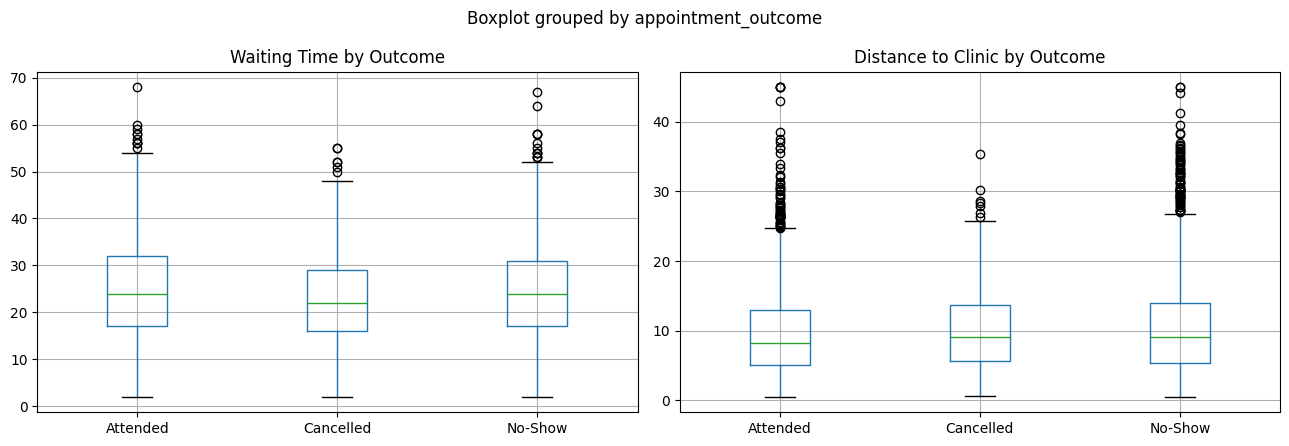

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df.boxplot(column='waiting_time_minutes', by='appointment_outcome', ax=axes[0])
axes[0].set_title('Waiting Time by Outcome')
axes[0].set_xlabel('')
plt.suptitle('')

df.boxplot(column='distance_to_clinic_km', by='appointment_outcome', ax=axes[1])
axes[1].set_title('Distance to Clinic by Outcome')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/waiting_distance_by_outcome.png', dpi=120)
plt.show()


In [5]:
print(df.groupby('appointment_outcome')[['waiting_time_minutes','distance_to_clinic_km']].median().round(1))


                     waiting_time_minutes  distance_to_clinic_km
appointment_outcome                                             
Attended                             24.0                    8.3
Cancelled                            22.0                    9.1
No-Show                              24.0                    9.1


**Observation:** medians are close across outcome groups for both variables — consistent
with Week 4's "weak signal" flag. Neither waiting time nor distance alone strongly separates
Attended from No-Show. Worth testing in combination with other variables (e.g. distance ×
reminder channel) in Week 6, but not a standalone driver.

### 4.2 Cancellations specifically (not lumped with No-Show)

In [6]:
cancel_df = df[df['appointment_outcome'] == 'Cancelled']
print(f"Cancelled appointments: {len(cancel_df)} ({len(cancel_df)/len(df):.1%} of total)")
print()
print("Cancellation rate by appointment_type:")
print((df.groupby('appointment_type')['appointment_outcome']
        .apply(lambda s: (s == 'Cancelled').mean())).round(3))
print()
print("Cancellation rate by booking_lead_days bucket:")
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,45,60],
                           labels=['0-7','8-14','15-30','31-45','46-60'])
print((df.groupby('lead_bucket', observed=True)['appointment_outcome']
        .apply(lambda s: (s == 'Cancelled').mean())).round(3))


Cancelled appointments: 263 (5.3% of total)

Cancellation rate by appointment_type:
appointment_type
Diagnostic Test            0.044
Follow-up                  0.054
General Consultation       0.051
Specialist Consultation    0.060
Name: appointment_outcome, dtype: float64

Cancellation rate by booking_lead_days bucket:
lead_bucket
0-7      0.056
8-14     0.047
15-30    0.051
31-45    0.056
46-60    0.051
Name: appointment_outcome, dtype: float64


**Observation:** cancellation rate stays roughly flat (~5%) across appointment types and
lead-time buckets — unlike no-show rate, which climbs sharply with lead time. This supports
treating Cancelled as a genuinely different operational event from No-Show (planned vs.
unplanned non-attendance), as assumed in Week 4.

### 4.3 Patient-history interaction: lead time × prior no-shows

In [7]:
pivot = df.pivot_table(
    index='lead_bucket', columns=pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,10],
                                          labels=['0','1','2','3+']),
    values='appointment_outcome', aggfunc=lambda s: (s == 'No-Show').mean(), observed=True
).round(2)
pivot.columns.name = 'previous_no_shows'
pivot


previous_no_shows,0,1,2,3+
lead_bucket,,,,
0-7,0.22,0.33,0.49,0.20
8-14,0.32,0.32,0.46,0.60
15-30,0.38,0.47,0.53,0.81
31-45,0.49,0.60,0.62,0.68
46-60,0.62,0.74,0.80,0.91


**Observation:** the two strong Week 4 signals compound. Even at the shortest lead time
(0–7 days), a patient with 3+ prior no-shows still shows a materially higher no-show rate than
a first-time patient booked far in advance — suggesting prior history matters somewhat
independently of lead time, not just as a proxy for it. This is useful for KPI 5 (Repeat
No-Show Rate) and for segment targeting (Q5).

## 5. KPI Development — Calculated

The 5 KPIs identified and linked to business questions in Week 4 are calculated here in full,
each with definition, rationale, calculation, linked question, and interpretation.

### KPI 1 — No-Show Rate  \n**Linked question:** Q1

In [8]:
no_show_rate = (df['appointment_outcome'] == 'No-Show').mean()
print(f"No-Show Rate: {no_show_rate:.1%}")


No-Show Rate: 48.5%


**Definition:** No-Show appointments ÷ total scheduled appointments.
**Why it matters:** primary metric for the clinic's core pain point — wasted capacity.
**Interpretation:** at 48.5%, nearly half of all scheduled appointments in this dataset are
missed. This is a high baseline and confirms the scale of the problem described in the
business scenario.

### KPI 2 — Attendance Rate  \n**Linked question:** Q1

In [9]:
attendance_rate = (df['appointment_outcome'] == 'Attended').mean()
print(f"Attendance Rate: {attendance_rate:.1%}")


Attendance Rate: 46.3%


**Definition:** Attended ÷ total scheduled appointments.
**Why it matters:** complements No-Show Rate for capacity-planning context (Cancelled isn't
"missed capacity" in the same way — see KPI 3).
**Interpretation:** at 46.3%, well under half of scheduled slots are actually used by the
booked patient — the practical capacity utilisation problem HealthConnect needs to solve.

### KPI 3 — Cancellation Rate  \n**Linked question:** Q1, Q3

In [10]:
cancellation_rate = (df['appointment_outcome'] == 'Cancelled').mean()
print(f"Cancellation Rate: {cancellation_rate:.1%}")


Cancellation Rate: 5.3%


**Definition:** Cancelled ÷ total scheduled appointments.
**Why it matters:** separates planned non-attendance (advance notice, slot can be reallocated)
from unplanned no-shows (no notice, slot wasted).
**Interpretation:** at 5.3%, cancellations are a small share of non-attendance overall — the
much bigger problem is genuinely unplanned no-shows (48.5%), which is where intervention effort
should concentrate.

### KPI 4 — Reminder Effectiveness  \n**Linked question:** Q4

In [11]:
reminder_effect = df.groupby('reminder_sent')['appointment_outcome'].apply(lambda s: (s == 'No-Show').mean())
channel_effect = df[df['reminder_sent']=='Yes'].groupby('reminder_channel')['appointment_outcome'].apply(lambda s: (s == 'No-Show').mean())
print("No-show rate by reminder_sent:")
print(reminder_effect.round(3))
print("\nNo-show rate by reminder_channel (when sent):")
print(channel_effect.round(3))
print(f"\nEffectiveness (point difference, not-sent minus sent): {(reminder_effect['No']-reminder_effect['Yes']):.1%}")


No-show rate by reminder_sent:
reminder_sent
No     0.514
Yes    0.474
Name: appointment_outcome, dtype: float64

No-show rate by reminder_channel (when sent):
reminder_channel
Email       0.484
SMS         0.458
WhatsApp    0.498
Name: appointment_outcome, dtype: float64

Effectiveness (point difference, not-sent minus sent): 4.0%


**Definition:** No-show rate when a reminder was sent vs. not sent, broken down by channel.
**Why it matters:** directly measures whether the reminder programme — and which channel — is
worth the operational cost of running.
**Interpretation:** sending a reminder is associated with a ~4-point lower no-show rate
(47.4% vs 51.4%), and SMS performs best among channels tested. The effect is real but modest —
reminders alone are not sufficient to solve the no-show problem; they're one lever among several
(see recommendations, Section 7).

### KPI 5 — Repeat No-Show Rate  \n**Linked question:** Q2, Q5

In [12]:
repeat_no_show_share = (df['previous_no_shows'] >= 2).mean()
repeat_outcome_rate = df[df['previous_no_shows'] >= 2]['appointment_outcome'].apply(lambda s: s == 'No-Show').mean()
print(f"Share of appointments from patients with >=2 prior no-shows: {repeat_no_show_share:.1%}")
print(f"No-show rate within that segment: {repeat_outcome_rate:.1%}")


Share of appointments from patients with >=2 prior no-shows: 10.6%
No-show rate within that segment: 61.0%


**Definition:** share of appointments booked by patients with 2+ prior no-shows, and the
no-show rate within that segment.
**Why it matters:** identifies a concentrated high-risk group for targeted intervention rather
than treating all patients the same.
**Interpretation:** this segment's no-show rate is well above the 48.5% baseline, confirming
prior history is a strong, actionable predictor — a natural target for a stricter reminder
protocol or confirmation call, cheaper than intervening on the full patient base.

## 6. Visual Report / Analytical Dashboard

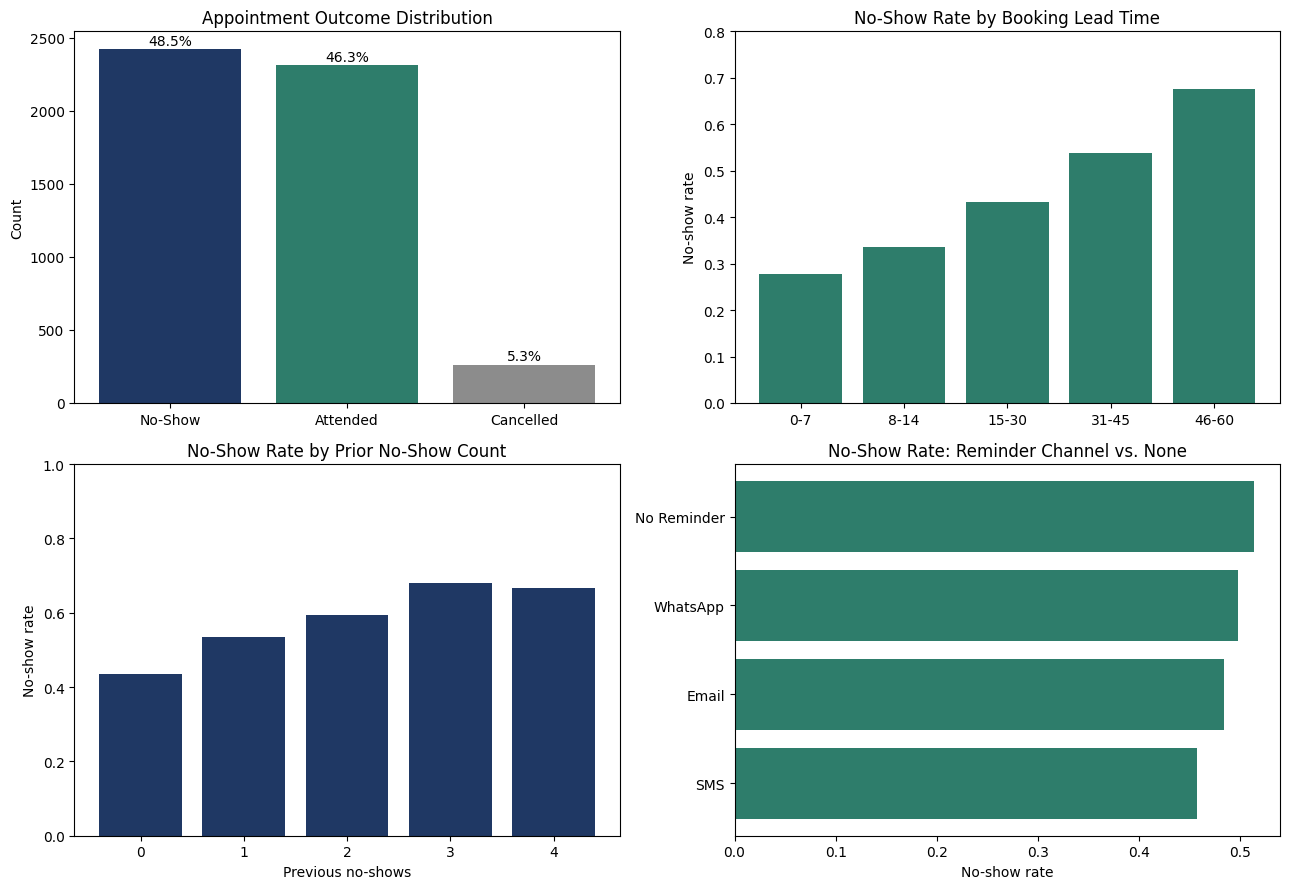

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Outcome split
outcome_counts = df['appointment_outcome'].value_counts()
axes[0,0].bar(outcome_counts.index, outcome_counts.values, color=[NAVY, TEAL, GREY])
axes[0,0].set_title('Appointment Outcome Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(outcome_counts.values):
    axes[0,0].text(i, v + 30, f"{v/len(df):.1%}", ha='center')

# 2. No-show rate by lead bucket
lead_rate = df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(lambda s: (s=='No-Show').mean())
axes[0,1].bar(lead_rate.index.astype(str), lead_rate.values, color=TEAL)
axes[0,1].set_title('No-Show Rate by Booking Lead Time')
axes[0,1].set_ylabel('No-show rate')
axes[0,1].set_ylim(0, 0.8)

# 3. No-show rate by prior no-shows
prior_rate = df[df['previous_no_shows']<=4].groupby('previous_no_shows')['appointment_outcome'].apply(lambda s: (s=='No-Show').mean())
axes[1,0].bar(prior_rate.index.astype(str), prior_rate.values, color=NAVY)
axes[1,0].set_title('No-Show Rate by Prior No-Show Count')
axes[1,0].set_xlabel('Previous no-shows')
axes[1,0].set_ylabel('No-show rate')
axes[1,0].set_ylim(0, 1.0)

# 4. Reminder effectiveness by channel
chan_rate = df[df['reminder_sent']=='Yes'].groupby('reminder_channel')['appointment_outcome'].apply(lambda s: (s=='No-Show').mean())
no_reminder_rate = df[df['reminder_sent']=='No']['appointment_outcome'].apply(lambda s: s=='No-Show').mean()
chan_rate['No Reminder'] = no_reminder_rate
chan_rate = chan_rate.sort_values()
axes[1,1].barh(chan_rate.index.astype(str), chan_rate.values, color=TEAL)
axes[1,1].set_title('No-Show Rate: Reminder Channel vs. None')
axes[1,1].set_xlabel('No-show rate')

plt.tight_layout()
plt.savefig('../outputs/week5_kpi_dashboard.png', dpi=120)
plt.show()


## 7. Business Insights & Recommendations

1. **Nearly half of appointments are missed (48.5% no-show).** This confirms the scale of the
   problem is significant enough to justify active intervention, not just monitoring.
2. **Booking lead time is the single clearest driver found** (28% → 68% no-show rate as lead
   time grows). *Implication:* HealthConnect could tighten booking windows for high-demand
   slots, or apply stronger reminder protocols specifically to appointments booked far in advance.
3. **Prior no-show history is a strong, independent risk signal**, even holding lead time
   constant. *Implication:* a "repeat no-show" flag could trigger a different workflow
   (confirmation call, deposit, or overbooking that slot) rather than treating every patient
   identically.
4. **Reminders help, but only modestly** (~4-point reduction), and SMS outperforms other
   channels. *Implication:* reminders alone won't fix a 48.5% no-show rate — they're a
   supporting lever, not the primary solution. Channel choice (favor SMS) is a low-cost, easy win.
5. **Cancellations are a small, stable ~5% and behave differently from no-shows** — they don't
   climb with lead time the way no-shows do. *Implication:* cancellation handling (rebooking the
   freed slot) is a separate, simpler operational process from the no-show problem and shouldn't
   be conflated with it in intervention design.
6. **Waiting time and distance to clinic are not strong standalone predictors** in this dataset.
   *Implication:* effort is better spent on the levers above (lead time policy, patient history,
   reminder channel) than on clinic-location or wait-time initiatives, based on this evidence.


## 8. Cross-Track Collaboration Note

- **Track interacted with (conceptually):** Data Science.
- **Information/output exchanged:** the variable-signal findings from this notebook —
  specifically that `booking_lead_days` and `previous_no_shows` are strong predictors,
  `reminder_sent`/`reminder_channel` are moderate, and `distance_to_clinic_km` /
  `waiting_time_minutes` are weak — are the natural candidate-feature shortlist for a no-show
  prediction model.
- **Why relevant:** the Data Science track's Week 4 output already proposed a similar feature
  set from its own review; this notebook provides the *quantified evidence* (actual rates, not
  just hypothesis) backing that choice.
- **What this informs going forward:** the Data Science track can prioritise
  `booking_lead_days`, `previous_no_shows`, and `reminder_sent`/`reminder_channel` as
  first-pass model features, and can deprioritise distance/waiting time unless a later
  interaction effect is found.


## 9. Assumptions, Limitations, Risks & Dependencies — Week 5 Update

| Item | Week 4 status | Week 5 status |
|---|---|---|
| Dataset is synthetic; findings are illustrative | Assumption | **Unchanged** — still holds |
| Cancelled treated as distinct from No-Show | Assumption | **Confirmed** — Section 4.2 shows cancellations behave differently (flat rate vs. lead time), supporting this as a validated assumption, not just a stated one |
| Missing data in distance/waiting time (<2%) | Limitation | **Unchanged / still open** — not yet addressed since these variables show weak signal anyway; lower priority for Week 6 |
| Sunday appointment records need stakeholder confirmation | Risk | **Unresolved** — still open, unaddressed this week; carried forward |
| Findings are associative, not causal | Risk | **Still relevant** — Week 5 added more association evidence (dashboard, KPIs) but no significance testing yet; this remains the top risk before findings are used to justify spend on interventions |
| New this week | — | **Interaction effects are underexplored** — Section 4.3 showed lead-time and prior-no-show effects compound; only one interaction was tested. Other combinations (e.g. reminder channel × prior history) are untested and could change the KPI-4 interpretation |


## 10. Limitations & Next Steps (Week 6 preview)

- All findings in this notebook are descriptive/associative. Statistical significance testing
  (chi-square, logistic regression) is still needed before treating any variable as a confirmed
  driver — this was flagged in Week 4 and remains the top methodological gap.
- Only one interaction (lead time × prior no-shows) was tested; other combinations remain unexplored.
- The Sunday-appointment and missing-data open items from Week 4 were not addressed this week —
  carried forward as-is.
- Week 6 focus: significance testing on the KPIs above, broader interaction analysis, and
  translating the 5 insights into a stakeholder-ready recommendation with estimated impact.

See `docs/HealthConnect_Week5_Analytics_Report.docx` for the full written report and
`docs/HealthConnect_Week5_Project_Summary.docx` for the concise Part 4 submission summary.
